In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
 
BASE      = r"c:\Users\mukul\Desktop\Projects\patient-readmission-prediction"
DATA_RAW  = os.path.join(BASE, "data", "raw")
DATA_PROC = os.path.join(BASE, "data", "processed")
REPORTS   = os.path.join(BASE, "reports")
 
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(REPORTS,   exist_ok=True)
 
sns.set_style("darkgrid")
plt.rcParams["figure.dpi"]     = 130
plt.rcParams["figure.figsize"] = (12, 5)
 
CYAN  = "#00e5ff"
RED   = "#ff4d6d"
GREEN = "#00f5a0"
AMBER = "#ffb347"
 
print("Setup complete ✅")
 

Setup complete ✅


In [5]:
df = pd.read_csv(os.path.join(DATA_RAW, r"C:\Users\mukul\Desktop\Projects\patient-readmission-prediction\data\processed\indian_patient_data.csv"))
df["admission_date"] = pd.to_datetime(df["admission_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"])
 
# Drop name — not useful for ML
df.drop(columns=["name"], inplace=True)
 
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Readmission rate: {df['readmitted_30_days'].mean():.1%}")
df.head(3)

Loaded: 10,000 rows × 22 columns
Readmission rate: 32.2%


,patient_id,age,gender,state,city,diagnosis,department,admission_date,discharge_date,length_of_stay_days,...,num_previous_admissions,num_medications,medications_prescribed,hba1c,blood_glucose_mg_dl,systolic_bp_mmhg,creatinine_mg_dl,haemoglobin_g_dl,total_charges_inr,readmitted_30_days
0,PTIND00001,26,Male,Tamil Nadu,Coimbatore,Hypertension,Emergency,2020-06-27,2020-06-29,2,...,3,1,Metformin,6.1,101,134,0.5,12.0,30318,0
1,PTIND00002,65,Female,Haryana,Faridabad,COPD,Pulmonology,2020-11-14,2020-11-20,6,...,1,2,"Insulin, Ramipril",4.0,119,147,0.4,10.8,82970,0
2,PTIND00003,27,Female,Odisha,Sambalpur,Dengue Fever,Nephrology,2023-12-13,2023-12-14,1,...,0,11,"Atenolol, Doxycycline, Atorvastatin, Insulin, ...",6.0,107,110,0.4,12.3,23416,0


In [6]:
# ── Gender ────────────────────────────────────────────────────────────────────
df["gender_encoded"] = df["gender"].map({"Male": 1, "Female": 0})
 
# ── Discharge Type ────────────────────────────────────────────────────────────
discharge_map = {
    "Home":                        0,
    "Home with Follow-up":         1,
    "Long-term Care Facility":     2,
    "Referred to Another Hospital":3,
    "Against Medical Advice":      4
}
df["discharge_encoded"] = df["discharge_type"].map(discharge_map)
 
# ── Insurance Type ────────────────────────────────────────────────────────────
insurance_map = {
    "Ayushman Bharat":       0,
    "State Government Scheme":1,
    "ESIC":                  2,
    "Private Insurance":     3,
    "None (Self-pay)":       4
}
df["insurance_encoded"] = df["insurance_type"].map(insurance_map)
 
# ── Diagnosis — One Hot Encode ────────────────────────────────────────────────
diagnosis_dummies = pd.get_dummies(df["diagnosis"], prefix="diag")
df = pd.concat([df, diagnosis_dummies], axis=1)
 
# ── State — One Hot Encode ────────────────────────────────────────────────────
state_dummies = pd.get_dummies(df["state"], prefix="state")
df = pd.concat([df, state_dummies], axis=1)
 
print(f"After encoding: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nNew encoded columns added:")
new_cols = ["gender_encoded","discharge_encoded","insurance_encoded"]
print([c for c in df.columns if c.startswith(("diag_","state_"))][:5], "... and more")
 

After encoding: 10,000 rows × 54 columns

New encoded columns added:
['diag_Anaemia', 'diag_Asthma', 'diag_COPD', 'diag_Chronic Kidney Disease', 'diag_Coronary Artery Disease'] ... and more


In [9]:
# ── Age-based features ────────────────────────────────────────────────────────
df["is_senior"]       = (df["age"] >= 65).astype(int)
df["is_very_elderly"] = (df["age"] >= 80).astype(int)

df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 35, 50, 65, 80, 95],
    labels=[0, 1, 2, 3, 4]
).cat.add_categories(-1).fillna(-1).astype(int)

# ── Stay-based features ───────────────────────────────────────────────────────
df["is_short_stay"]  = (df["length_of_stay_days"] <= 2).astype(int)
df["is_long_stay"]   = (df["length_of_stay_days"] > 10).astype(int)
df["cost_per_day"]   = (df["total_charges_inr"] / (df["length_of_stay_days"] + 1)).round(2)

df["stay_bucket"] = pd.cut(
    df["length_of_stay_days"],
    bins=[0, 2, 5, 10, 20, 45],
    labels=[0, 1, 2, 3, 4]
).cat.add_categories(-1).fillna(-1).astype(int)

# ── Admission history features ────────────────────────────────────────────────
df["is_repeat_patient"]   = (df["num_previous_admissions"] >= 2).astype(int)
df["is_frequent_patient"] = (df["num_previous_admissions"] >= 4).astype(int)

# ── Medication features ───────────────────────────────────────────────────────
df["is_high_medications"] = (df["num_medications"] >= 8).astype(int)
df["is_polypharmacy"]     = (df["num_medications"] >= 10).astype(int)

# ── Discharge risk features ───────────────────────────────────────────────────
df["no_followup"]   = (df["discharge_type"] == "Home").astype(int)
df["ama_discharge"] = (df["discharge_type"] == "Against Medical Advice").astype(int)
df["has_followup"]  = (df["discharge_type"] == "Home with Follow-up").astype(int)

# ── Insurance features ────────────────────────────────────────────────────────
df["no_insurance"]   = (df["insurance_type"] == "None (Self-pay)").astype(int)
df["govt_insurance"] = (df["insurance_type"].isin(
    ["Ayushman Bharat", "State Government Scheme", "ESIC"]
)).astype(int)

# ── Lab result features ───────────────────────────────────────────────────────
df["poor_diabetes_control"] = (
    (df["diagnosis"] == "Type 2 Diabetes") & (df["hba1c"] > 9)
).astype(int)

df["high_hba1c"]      = (df["hba1c"] > 9).astype(int)
df["high_glucose"]    = (df["blood_glucose_mg_dl"] > 200).astype(int)
df["high_bp"]         = (df["systolic_bp_mmhg"] > 140).astype(int)
df["high_creatinine"] = (df["creatinine_mg_dl"] > 1.5).astype(int)
df["low_haemoglobin"] = (df["haemoglobin_g_dl"] < 10).astype(int)

# ── High risk diagnosis flags ─────────────────────────────────────────────────
HIGH_RISK_DIAG = ["Chronic Kidney Disease", "COPD", "Heart Failure"]
df["is_high_risk_diag"] = df["diagnosis"].isin(HIGH_RISK_DIAG).astype(int)

# ── Print summary ─────────────────────────────────────────────────────────────
print("Clinical features created ✅")
print(f"\nNew features:")

new_features = [
    "is_senior", "is_very_elderly",
    "is_short_stay", "is_long_stay", "cost_per_day",
    "is_repeat_patient", "is_frequent_patient",
    "is_high_medications", "is_polypharmacy",
    "no_followup", "ama_discharge", "has_followup",
    "no_insurance", "govt_insurance",
    "poor_diabetes_control", "high_hba1c", "high_glucose",
    "high_bp", "high_creatinine", "low_haemoglobin",
    "is_high_risk_diag"
]

for f in new_features:
    if f in df.columns:
        rate = df.groupby(f)["readmitted_30_days"].mean()
        if 1 in rate.index:
            print(f"  {f:<30} → readmission when=1: {rate[1]:.1%}")
    else:
        print(f"  {f:<30} → skipped (not found)")

Clinical features created ✅

New features:
  is_senior                      → readmission when=1: 39.3%
  is_very_elderly                → readmission when=1: 50.7%
  is_short_stay                  → readmission when=1: 37.7%
  is_long_stay                   → readmission when=1: 27.7%
  is_repeat_patient              → readmission when=1: 44.9%
  is_frequent_patient            → readmission when=1: 52.0%
  is_high_medications            → readmission when=1: 36.4%
  is_polypharmacy                → readmission when=1: 36.8%
  no_followup                    → readmission when=1: 35.6%
  ama_discharge                  → readmission when=1: 45.1%
  has_followup                   → readmission when=1: 26.4%
  no_insurance                   → readmission when=1: 30.8%
  govt_insurance                 → readmission when=1: 33.0%
  poor_diabetes_control          → readmission when=1: 45.0%
  high_hba1c                     → readmission when=1: 44.5%
  high_glucose                   → readmis

Risk score distribution:
count    10000.00
mean         5.03
std          2.91
min          0.00
25%          3.00
50%          5.00
75%          7.00
max         17.00
Name: risk_score, dtype: float64

Correlation with readmission: 0.299


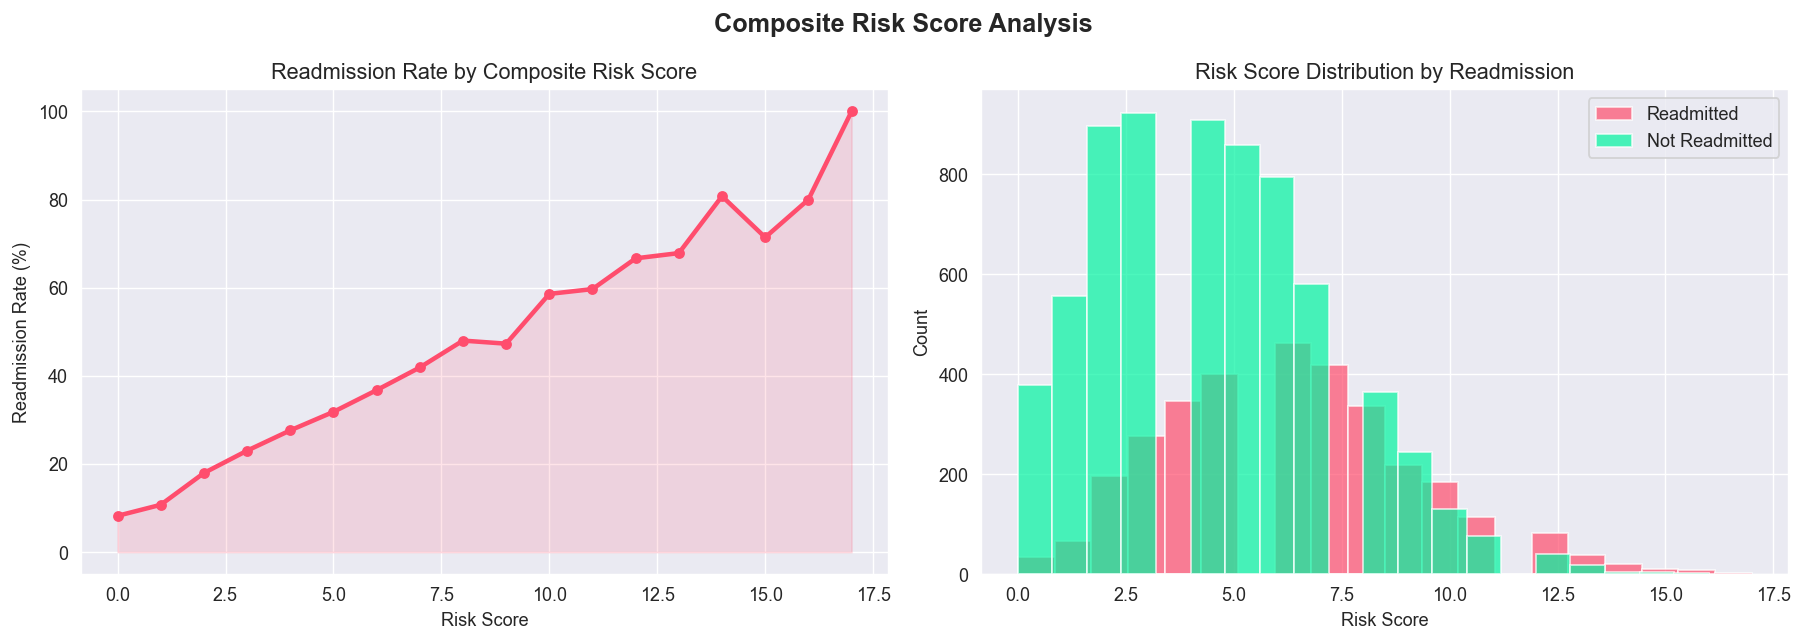

In [10]:
df["risk_score"] = (
    df["is_senior"]           * 2 +
    df["is_very_elderly"]     * 2 +
    df["is_short_stay"]       * 2 +
    df["is_repeat_patient"]   * 2 +
    df["is_frequent_patient"] * 2 +
    df["is_high_risk_diag"]   * 3 +
    df["poor_diabetes_control"] * 2 +
    df["is_high_medications"] * 1 +
    df["no_followup"]         * 2 +
    df["ama_discharge"]       * 4 +
    df["no_insurance"]        * 1 +
    df["high_creatinine"]     * 1 +
    df["low_haemoglobin"]     * 1 +
    df["high_bp"]             * 1
)
 
print("Risk score distribution:")
print(df["risk_score"].describe().round(2))
print(f"\nCorrelation with readmission: {df['risk_score'].corr(df['readmitted_30_days']):.3f}")
 
# Plot risk score vs readmission
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
risk_rate = df.groupby("risk_score")["readmitted_30_days"].mean() * 100
axes[0].plot(risk_rate.index, risk_rate.values,
             color=RED, linewidth=2.5, marker="o", markersize=5)
axes[0].set_xlabel("Risk Score")
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].set_title("Readmission Rate by Composite Risk Score")
axes[0].fill_between(risk_rate.index, risk_rate.values, alpha=0.15, color=RED)
 
axes[1].hist(df[df["readmitted_30_days"]==1]["risk_score"], bins=20,
             alpha=0.7, color=RED, label="Readmitted", edgecolor="white")
axes[1].hist(df[df["readmitted_30_days"]==0]["risk_score"], bins=20,
             alpha=0.7, color=GREEN, label="Not Readmitted", edgecolor="white")
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk Score Distribution by Readmission")
axes[1].legend()
 
plt.suptitle("Composite Risk Score Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "10_risk_score.png"), bbox_inches="tight")
plt.show()
 

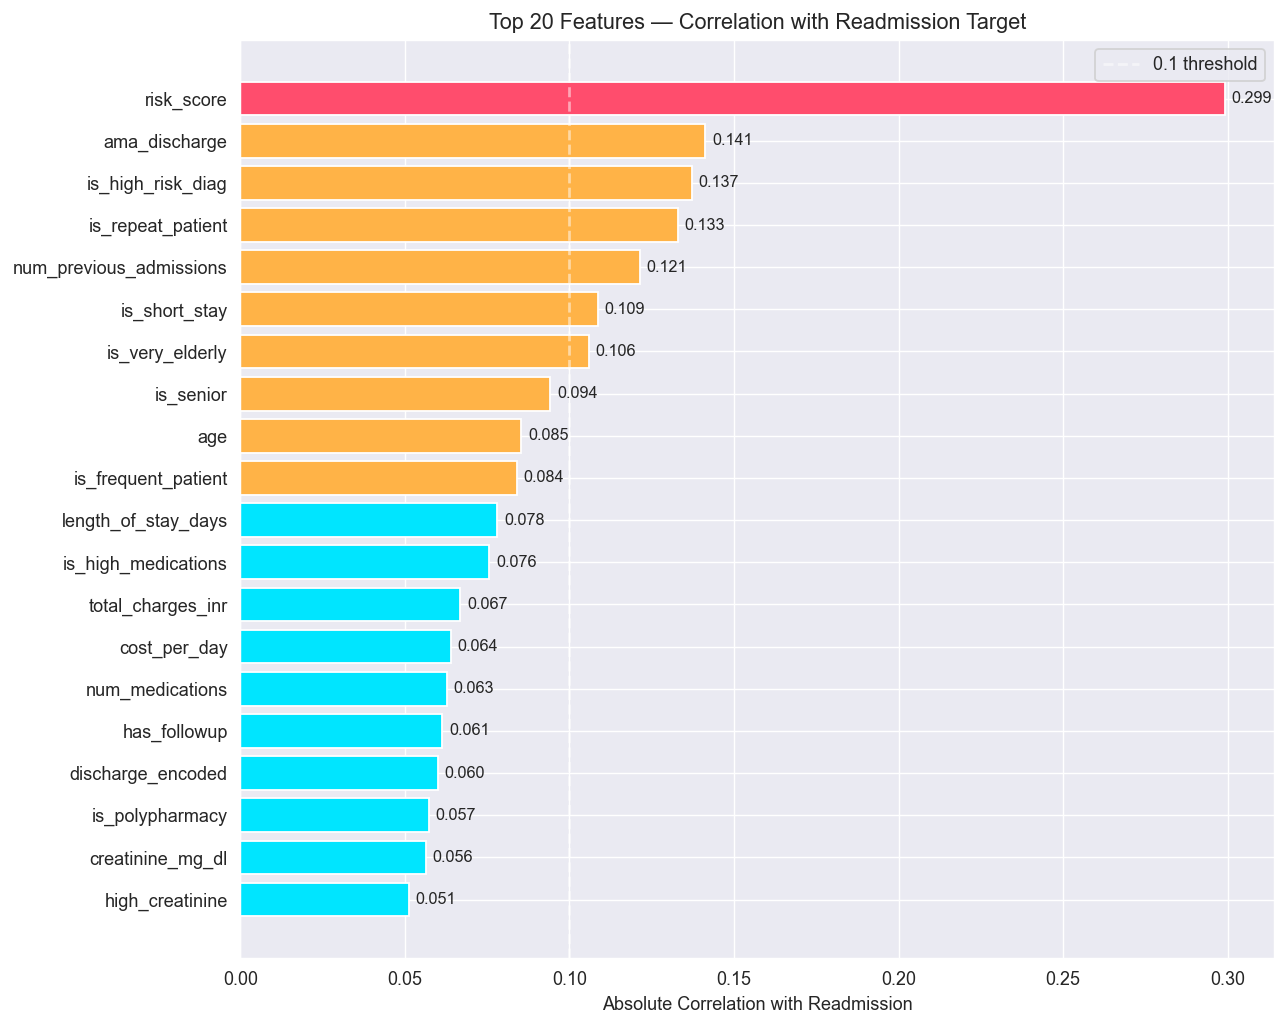


Top 10 features by correlation:
  risk_score                          0.2991
  ama_discharge                       0.1413
  is_high_risk_diag                   0.1373
  is_repeat_patient                   0.1330
  num_previous_admissions             0.1213
  is_short_stay                       0.1086
  is_very_elderly                     0.1058
  is_senior                           0.0942
  age                                 0.0854
  is_frequent_patient                 0.0840


In [11]:
ml_cols = [
    "age", "length_of_stay_days", "num_previous_admissions",
    "num_medications", "hba1c", "blood_glucose_mg_dl",
    "systolic_bp_mmhg", "creatinine_mg_dl", "haemoglobin_g_dl",
    "total_charges_inr", "cost_per_day", "risk_score",
    "is_senior", "is_very_elderly", "is_short_stay",
    "is_repeat_patient", "is_frequent_patient",
    "is_high_medications", "is_polypharmacy",
    "no_followup", "ama_discharge", "has_followup",
    "no_insurance", "govt_insurance",
    "poor_diabetes_control", "high_hba1c", "high_glucose",
    "high_bp", "high_creatinine", "low_haemoglobin",
    "is_high_risk_diag", "gender_encoded",
    "discharge_encoded", "insurance_encoded",
    "readmitted_30_days"
]
 
corr_target = (
    df[ml_cols]
    .corr()["readmitted_30_days"]
    .drop("readmitted_30_days")
    .abs()
    .sort_values(ascending=True)
)
 
# Plot top 20 correlations
top20 = corr_target.tail(20)
 
fig, ax = plt.subplots(figsize=(10, 8))
colors = [RED if v > 0.15 else AMBER if v > 0.08 else CYAN for v in top20.values]
bars = ax.barh(top20.index, top20.values, color=colors, edgecolor="white")
ax.set_xlabel("Absolute Correlation with Readmission")
ax.set_title("Top 20 Features — Correlation with Readmission Target")
ax.axvline(0.1, color="white", linestyle="--", alpha=0.5, label="0.1 threshold")
ax.legend()
for bar, val in zip(bars, top20.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
 
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "11_feature_correlation.png"), bbox_inches="tight")
plt.show()
 
print("\nTop 10 features by correlation:")
for feat, val in corr_target.tail(10).sort_values(ascending=False).items():
    print(f"  {feat:<35} {val:.4f}")
 

In [12]:
save_cols = ["patient_id"] + ml_cols
df_processed = df[save_cols].copy()
 
output_path = os.path.join(DATA_PROC, "patient_processed.csv")
df_processed.to_csv(output_path, index=False)
 
print(f"Saved processed dataset:")
print(f"  Path    : {output_path}")
print(f"  Shape   : {df_processed.shape[0]:,} rows × {df_processed.shape[1]} columns")
print(f"  Features: {df_processed.shape[1] - 2} ML features + patient_id + target")
print(f"\n✅ Feature Engineering Complete — Ready for Model Training (Notebook 03)")
 

Saved processed dataset:
  Path    : c:\Users\mukul\Desktop\Projects\patient-readmission-prediction\data\processed\patient_processed.csv
  Shape   : 10,000 rows × 36 columns
  Features: 34 ML features + patient_id + target

✅ Feature Engineering Complete — Ready for Model Training (Notebook 03)
